In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
queries_path = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/queries.bin"
doc_path = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/documents.bin"

In [3]:
import struct
from tqdm import tqdm

def read_sparse_vectors_from_binary_file(filename):
    """
    Reads a binary file in the format produced by write_sparse_vectors_to_binary_file:
      [N_terms  : uint32]
      For each of N_terms:
        [L       : uint32]
        [idx_1..idx_L : L × uint32]
        [val_1..val_L : L × float32]
    Returns a list of dicts mapping each idx_i to val_i.
    """
    vectors = []
    with open(filename, "rb") as fin:
        # Read number of term‐dicts
        raw = fin.read(4)
        if len(raw) < 4:
            raise EOFError("Unexpected end of file when reading number of vectors")
        n_terms, = struct.unpack("<I", raw)

        for _ in tqdm(range(n_terms), desc="Reading term vectors"):
            # Read vector length L
            raw = fin.read(4)
            if len(raw) < 4:
                raise EOFError("Unexpected end of file when reading vector length")
            L, = struct.unpack("<I", raw)

            # Read L indices (uint32)
            idx_bytes = fin.read(4 * L)
            if len(idx_bytes) < 4 * L:
                raise EOFError("Unexpected end of file when reading indices")
            indices = struct.unpack(f"<{L}I", idx_bytes)

            # Read L float32 values
            val_bytes = fin.read(4 * L)
            if len(val_bytes) < 4 * L:
                raise EOFError("Unexpected end of file when reading values")
            values = struct.unpack(f"<{L}f", val_bytes)

            # Build dict and append
            vectors.append({idx: val for idx, val in zip(indices, values)})

    return vectors

In [4]:
queries = read_sparse_vectors_from_binary_file(queries_path)

Reading term vectors: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6980/6980 [00:00<00:00, 117664.11it/s]


In [6]:
import struct

from tqdm import tqdm
import struct 
import numpy as np

def read_u16_slice_bincode(path: str):
    with open(path, "rb") as f:
        data = f.read()

    offset = 0

    # 1. Legge la lunghezza della slice (u64, little endian)
    (length,) = struct.unpack_from("<Q", data, offset)
    offset += 8

    # 2. Legge tutti gli elementi (u16, little endian)
    values = list(struct.unpack_from(f"<{length}H", data, offset))

    return values

In [8]:
permutation = read_u16_slice_bincode("/home/cosimorulli/next_develop_seismic/seismic_private/cached_permutation_10063359830016043830")

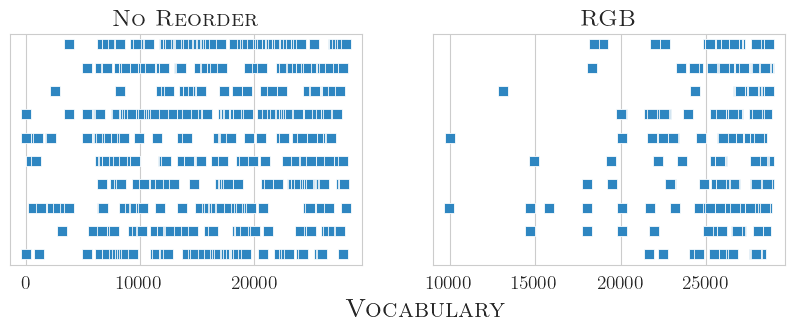

In [30]:
import matplotlib.pyplot as plt

n_queries = 10
queries_ids = np.random.choice(len(queries), n_queries)

sns.set_style("whitegrid")
# Enable TeX rendering and configure font sizes
plt.rc('text', usetex=True)
plt.rc('font', family='serif')  # use LaTeX serif font
MEDIUM_SIZE = 19
BIGGER_SIZE = 25

plt.rc('font', size=MEDIUM_SIZE)
plt.rc('axes', titlesize=MEDIUM_SIZE - 2)
plt.rc('axes', labelsize=MEDIUM_SIZE - 2)
plt.rc('xtick', labelsize=MEDIUM_SIZE - 5)
plt.rc('ytick', labelsize=MEDIUM_SIZE)
plt.rc('legend', fontsize=MEDIUM_SIZE - 2)
plt.rc('figure', titlesize=MEDIUM_SIZE)



n_cols = 2
fig, (ax1, ax2) = plt.subplots(1, n_cols, sharey=True, figsize=(10, 3))

ax1.set_yticks(np.arange(n_queries))
ax1.set_title(r"\textsc{No Reorder}")
#ax1.set_yticklabels([f"Q{i+1}" for i in np.arange(n_queries)])

# ax2.set_yticks([])
# ax2.set_title(r"\textsc{Metis}")


ax2.set_yticks([])
ax2.set_title(r"\textsc{RGB}")



colors = ["#2E86C1", "#28B463", "#F39C12", "#D35400", "#8E44AD"]
sns.set_palette(colors)


#metis_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_metis_8edf21a894a9745b.txt"
#metis_permutation = np.loadtxt(metis_permutation_path)

xs = []
ys = []

for i , idx in enumerate(queries_ids):
    query = queries[idx]
    components = list(query.keys())
    xs.extend(components)
    ys.extend([i] * len(components))
sns.scatterplot(x=xs, y=ys, ax=ax1, marker="s", s=50)



# xs_perm = []
# ys_perm = []
# for i , idx in enumerate(queries_ids):
#     query = queries[idx]
#     components_perm = [metis_permutation[x] for x in list(query.keys())]
#     xs_perm.extend(components_perm)
#     ys_perm.extend([i] * len(components_perm))
# sns.scatterplot(x=xs_perm, y=ys_perm, ax=ax2, marker="s", s=50)


#rgb_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_graph_bisection_6f13c60c0609ee4f.txt"
#rgb_permutation = np.loadtxt(rgb_permutation_path)

xs_perm_rgb = []
ys_perm_rgb = []
for i , idx in enumerate(queries_ids):
    query = queries[idx]
    components_perm_rgb = [permutation[x] for x in list(query.keys())]
    xs_perm_rgb.extend(components_perm_rgb)
    ys_perm_rgb.extend([i] * len(components_perm_rgb))
sns.scatterplot(x=xs_perm_rgb, y=ys_perm_rgb, ax=ax2, marker="s", s=50)

fig.text(x=0.54, y=-0.06, s=r"\textsc{Vocabulary}", ha='center')

plt.savefig("query_reordering.pdf", dpi=300, bbox_inches="tight")



In [43]:
components = np.array(components)

In [44]:
left_diff = [-1] + list(components[1:] - components[:-1])

In [45]:
def find_consecutives(components):
    consecutives = []
    for (i, c) in enumerate(components):
        if i==0:
            consecutives.append(c == components[i+1] + 1)
            continue
        if i == len(components) - 1:
            consecutives.append(c == components[i-1] - 1)
            continue
    
        consecutives.append(c- 1== components[i-1] or c + 1== components[i+1])
    return consecutives

In [16]:
document = read_sparse_vectors_from_binary_file(doc_path)

Reading term vectors: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [02:47<00:00, 52829.46it/s]


In [19]:
lens = np.array([len(x) for x in document])

In [26]:
doc_ids = np.random.choice(np.where(lens < 100)[0], 10)

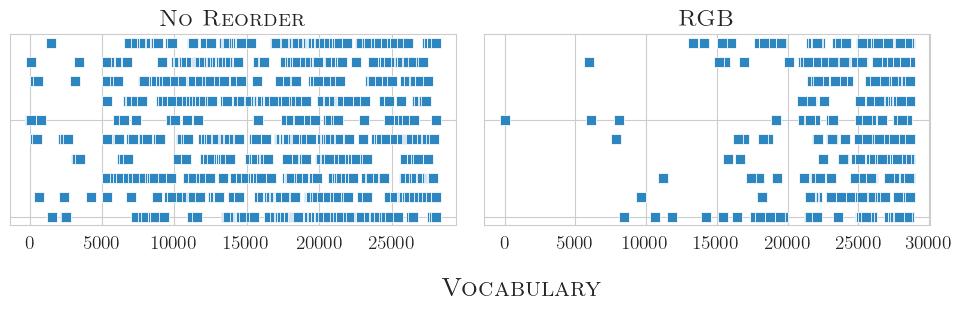

In [136]:
import matplotlib.pyplot as plt

sns.set_style("whitegrid")



plt.rc('text', usetex=True)
plt.rc('font', family='serif')  # use LaTeX serif font
MEDIUM_SIZE = 19
BIGGER_SIZE = 25

plt.rc('font', size=MEDIUM_SIZE)
plt.rc('axes', titlesize=MEDIUM_SIZE - 2)
plt.rc('axes', labelsize=MEDIUM_SIZE - 2)
plt.rc('xtick', labelsize=MEDIUM_SIZE - 5)
plt.rc('ytick', labelsize=MEDIUM_SIZE)
plt.rc('legend', fontsize=MEDIUM_SIZE - 2)
plt.rc('figure', titlesize=MEDIUM_SIZE)
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(10, 3))

xs = []
ys = []

for i , idx in enumerate(doc_ids):
    doc = document[idx]
    components = list(doc.keys())
    xs.extend(components)
    ys.extend([i] * len(components))
sns.scatterplot(x=xs, y=ys, ax=ax1, marker="s", s=50)

ax1.set_title(r"\textsc{No Reorder}")
ax1.set_ylabel("")
ax1.set_yticklabels([])
ax2.set_title(r"\textsc{RGB}")
ax2.set_ylabel("")

xs_perm = []
ys_perm = []
for i , idx in enumerate(doc_ids):
    doc = document[idx]
    components_perm = [permutation[x] for x in list(doc.keys())]
    xs_perm.extend(components_perm)
    ys_perm.extend([i] * len(components_perm))
fig.text(x=0.54, y=-0.05, s=r"\textsc{Vocabulary}", ha='center')
sns.scatterplot(x=xs_perm, y=ys_perm, ax=ax2, marker="s", s=50)
plt.tight_layout()
plt.savefig("document_reordering.pdf", dpi=300, bbox_inches="tight")

In [94]:
len(components_perm)

96

In [40]:
from collections import Counter

delta_counter_permuted = Counter()
delta_counter = Counter()
for doc in tqdm(document):
    components = np.fromiter(doc.keys(), dtype=int)
    original_diffs = components[1:] - components[:-1]
    delta_counter.update(original_diffs)
    converted_and_sorted = np.sort(np.array([permutation[x] for x in components]))
    diffs = converted_and_sorted[1:] - converted_and_sorted[:-1]
    delta_counter_permuted.update(diffs)



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [10:34<00:00, 13937.55it/s]


In [89]:
xs, ys = zip(*delta_counter.most_common())
xs_perm, ys_perm = zip(*delta_counter_permuted.most_common())

In [90]:
xs = np.array(list(xs))
ys = np.array(list(ys))

xs_perm = np.array(list(xs_perm))
ys_perm = np.array(list(ys_perm))

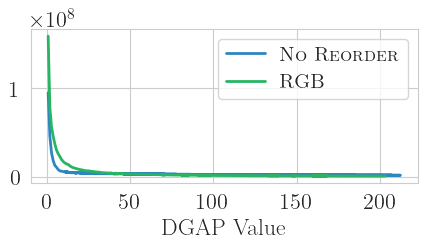

In [93]:
limit = 200


plt.rc('font', size=MEDIUM_SIZE)
plt.rc('axes', titlesize=MEDIUM_SIZE - 2)
plt.rc('axes', labelsize=MEDIUM_SIZE - 2)
plt.rc('xtick', labelsize=MEDIUM_SIZE - 3)
plt.rc('ytick', labelsize=MEDIUM_SIZE - 3)
plt.rc('legend', fontsize=MEDIUM_SIZE - 5)
plt.rc('figure', titlesize=MEDIUM_SIZE)
fig, ax1 = plt.subplots(ncols=1, figsize=(5, 2),sharey=True)


plt.plot(xs[:limit], ys[:limit], label=r"\textsc{No Reorder}", linewidth=2)
plt.plot(xs_perm[:limit], ys_perm[:limit], label=r"\textsc{RGB}", linewidth=2)
plt.xlabel("DGAP Value")
plt.legend()

In [97]:
ys_perm[xs_perm == 256]

array([325011])

In [98]:
ys_perm[xs_perm == 255]

array([338590])

In [108]:
(ys_perm[0] * 3 / 8) / 1024 **2

57.01543414592743

In [109]:
(ys_perm[2] / 8) / 1024 **2

6.728583455085754

In [110]:
(ys_perm[6] * 3 / 8) / 1024 **2

9.229091763496399

In [111]:
def len_gamma(n, use_table=False):
    
    n += 1  
    λ = n.bit_length() - 1  # equivalente a ilog2 in Rust
    return 2 * λ + 1

In [121]:
bits_diff_gamma = np.sum([(len_gamma(int(x) ) - len_gamma(int(x) - 1)) * y for (x,y) in zip(xs_perm, ys_perm)])
bytes_diff_gamma = bits_diff_gamma / (8 * 1024**2)
print("Mega Bytes diff gamma", bytes_diff_gamma)

Bytes diff gamma 62.30710029602051


In [131]:
np.sum([len_gamma(int(x) - 1) * y for (x,y) in zip(xs_perm, ys_perm)]) / ( 8 * 1024**2)

1046.8796118497849

In [122]:
def len_delta(n, use_table=False):
    λ = (n + 1).bit_length() - 1  
    return λ + len_gamma(λ, use_table=use_table)

In [127]:
bits_diff_delta = np.sum([(len_delta(int(x) ) - len_delta(int(x) - 1)) * y for (x,y) in zip(xs_perm, ys_perm)])
bytes_diff_delta = bits_diff_delta / (8 * 1024**2)
print("Bytes diff delta", bytes_diff_delta)

Bytes diff delta 75.54269766807556


In [130]:
np.sum([len_delta(int(x) - 1) * y for (x,y) in zip(xs_perm, ys_perm)]) / ( 8 * 1024**2)

991.7345805168152

In [125]:
bits_diff_delta

633698078